# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [2]:
# Uncomment and run if required
#! pip install transformers torchvision torch accelerate
#uv add --active transformers==4.51.0 #useful to Downgrade the package

In [3]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

Using device: cpu


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [4]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(
    root="./awesome_fashion_data",
    train=False,
    download=True
)
test_loader =DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_clip
)

If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

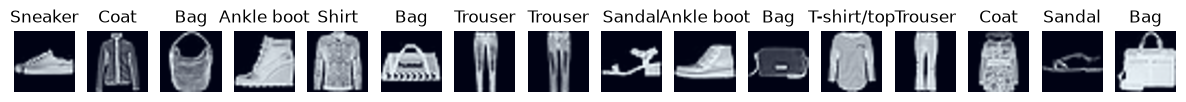

In [5]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [6]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [7]:
import numpy as np
import torch.nn.functional as F

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    similarity=F.cosine_similarity(image_feats.unsqueeze(1), text_feats.unsqueeze(0), dim=2)
    return similarity # Complete

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    index= np.argmax(similarity, axis=1)
    return index # Complete

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm
y_true, y_pred = [], []


for pixel_values, labels in tqdm(test_loader):
#Build text embeddings for the class names using the get_text_embeddings function (this only needs to be done once).
    text_feats = get_text_embeddings(CLASS_NAMES)
# Get image embeddings using the get_image_embeddings function.
    image_embeddings = get_image_embeddings(pixel_values)
#Compute cosine similarity between the image and text embeddings using the get_cosine_similarity function.
    similarity_scores = get_cosine_similarity(image_embeddings, text_feats)
# Save the predictions so that we can build a confusion matrix later.
    predictions = get_predictions(similarity_scores)

    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predictions.cpu().numpy())

# Report the accuracy of the predictions
#Report the accuracy of the predictions and the confusion matrix using the accuracy_score and confusion_matrix functions from sklearn.metrics
acc = accuracy_score(y_true, y_pred)
print(f"Zero-shot CLIP accuracy: {acc:.4f}")

# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

100%|██████████| 625/625 [30:28<00:00,  2.93s/it]  

Zero-shot CLIP accuracy: 0.6240


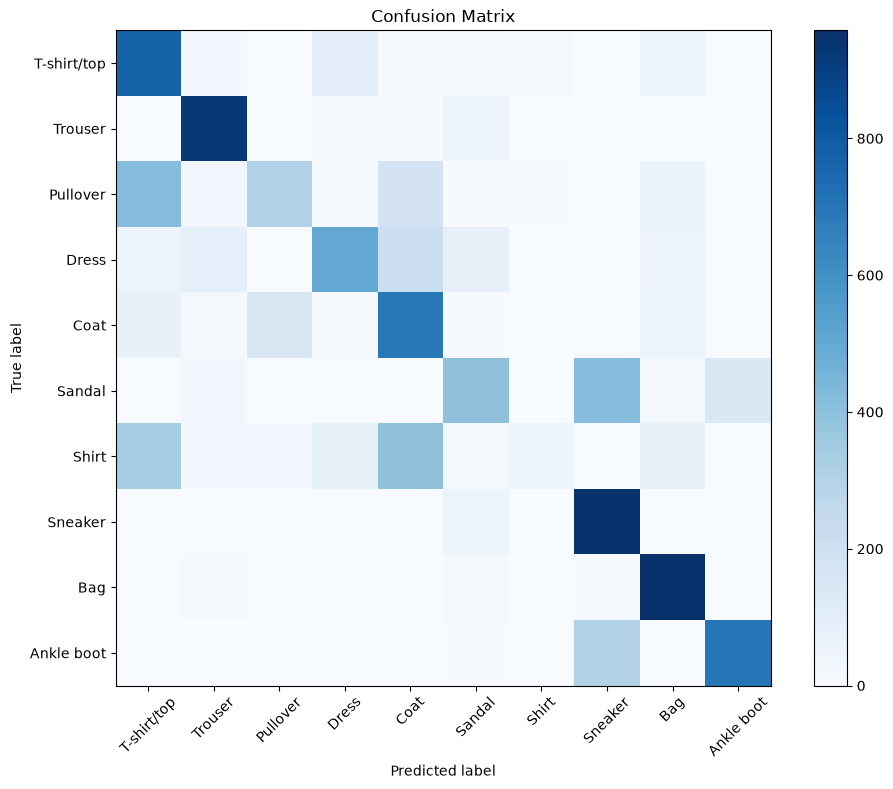

In [11]:
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

In Assignment 1, the CNN achieved 90.40% of test accuracy, it performed much better than the zero-shot baseline model (it only achives 62.40% accuracy). 
The CNN requires more training time, but once trained, it makes predictions very quickly because it has learned detailed features that help distinguish clothing iteams effectively. On the other hand, the zero-shot baseline model can classify new categories without retraining. However, its accuracy is significantly lower than the CNN's

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

100%|██████████| 625/625 [25:14<00:00,  2.42s/it]


Zero-shot CLIP accuracy: 0.6773


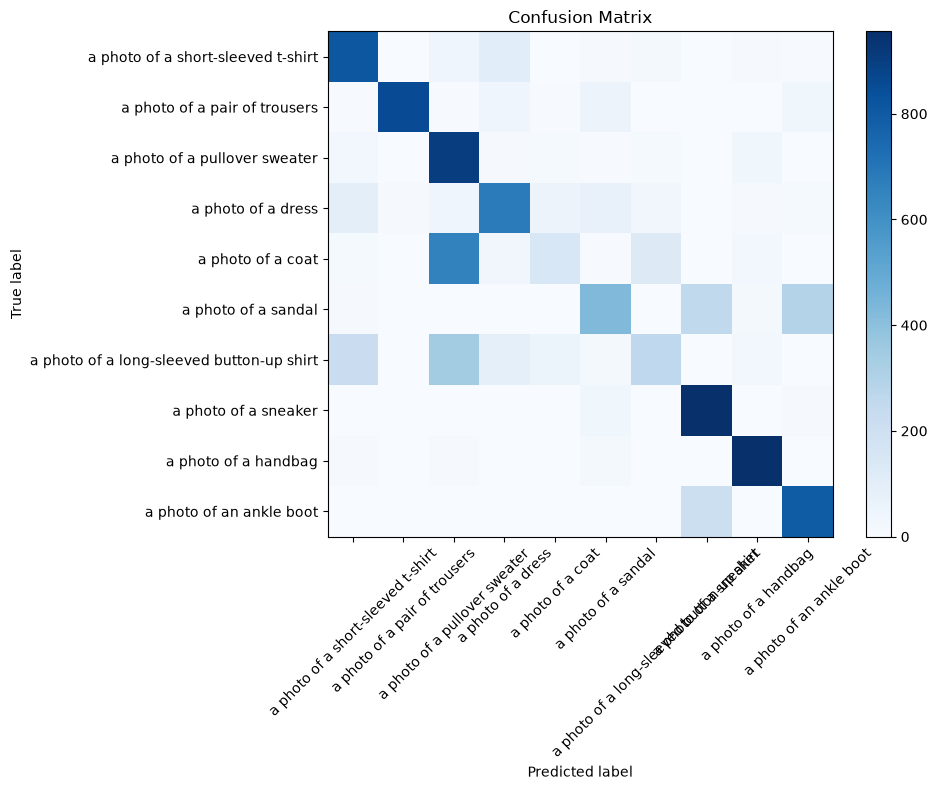

In [ ]:
#Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
improved_prompts = [
    "a photo of a short-sleeved t-shirt",
    "a photo of a pair of trousers",
    "a photo of a pullover sweater",
    "a photo of a dress",
    "a photo of a coat",
    "a photo of a sandal",
    "a photo of a long-sleeved button-up shirt",
    "a photo of a sneaker",
    "a photo of a handbag",
    "a photo of an ankle boot",
]


y_true, y_pred = [], []
for pixel_values, labels in tqdm(test_loader):
#Use the get_text_embeddings function to create text embeddings for the improved prompts.
    text_feats = get_text_embeddings(improved_prompts)
    image_embeddings = get_image_embeddings(pixel_values)
    similarity_scores = get_cosine_similarity(image_embeddings, text_feats)
    predictions = get_predictions(similarity_scores)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predictions.cpu().numpy())


#Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.
acc = accuracy_score(y_true, y_pred)
print(f"Zero-shot CLIP accuracy: {acc:.4f}")
plot_confusion_matrix(y_true, y_pred, improved_prompts)





Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

Using more detailed prompts gave a small but clear improvement in the zero-shot baseline model's accuracy. The accuracy went up from about 62% to 67.73%.

I think the way we write prompts is important, because giving more context helps the model understand the image better and focus on the right type of clothing.

I believe we could improve the model further by using several prompts for each class, which could help reduce confusion between similar items for example pullover and coat
Also, not sure if it could be possible, I think it could be a good idea to combine the zero-shot with the CNN.


## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [ ]:
# Uncomment the following line to install UMAP if you haven't already
#! pip install umap-learn

In [11]:
from umap import UMAP
# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

for pixel_values, labels in tqdm(test_loader):
#Get image embeddings
    image_embeddings = get_image_embeddings(pixel_values)
#Store embeddings and labels
    all_img_emb.append(image_embeddings.cpu().numpy())
    all_labels.append(labels.cpu().numpy())

all_img_emb = np.vstack(all_img_emb)
all_labels = np.concatenate(all_labels)


100%|██████████| 625/625 [29:43<00:00,  2.85s/it]  


In [12]:
# Verify sizes
print(f"Labels shape: {all_labels.shape}")  # Should be (n_samples,)
print(f"Labels dtype: {all_labels.dtype}")  # Should be int


Labels shape: (10000,)
Labels dtype: int64


In [13]:
# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------

umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=1 )
embedding_2d = umap_model.fit_transform(all_img_emb)


c:\Users\garci\Documents\DSI\deep_learning\deep-learning-env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


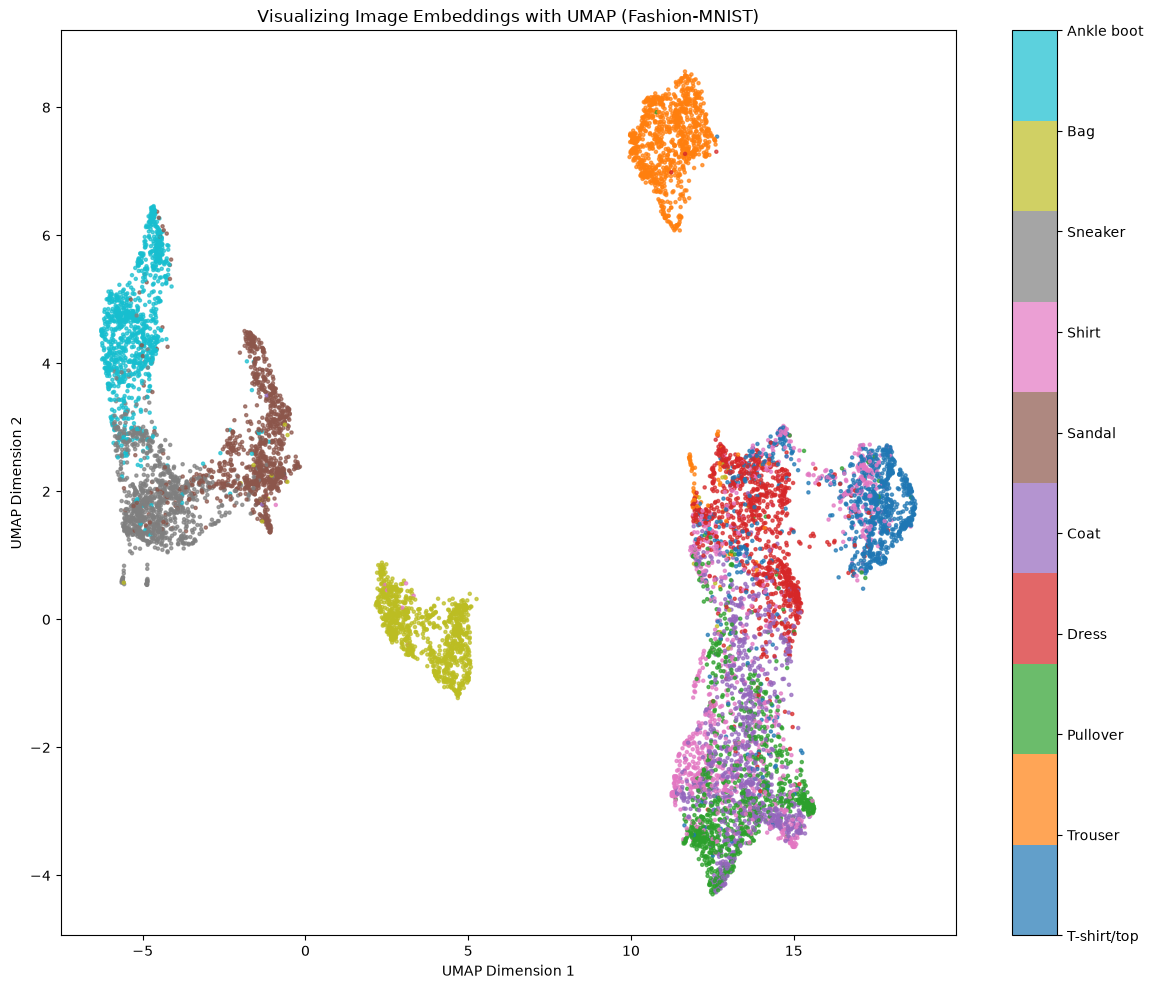

In [14]:
# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
plt.figure(figsize=(12, 10))
scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], 
                         c=all_labels, cmap='tab10', alpha=0.7, s=5)
    
# Add colorbar with class labels
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels(CLASS_NAMES)
    
plt.title('Visualizing Image Embeddings with UMAP (Fashion-MNIST)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.tight_layout()
plt.show()

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

Yes, I do. Based on this picture, the model finds it hard to separate clothes that have similar characteristics(eg. size, shape) like Pullover, Shirt, Coat, and Dress. But if an item has a very clear characteristics the model can recognize it better. For example, the T-Shirt/top blue section at the right.
I think Shirt and Coat are the most difficult to separate because they are overlapping to each other. \Some Trousers are near Dress, but most of them are far apart. I think this is because the model saw many Trousers during training.

Also, Ankle boots, Sneakers, and Sandals share some characteristics, so the model might get confused sometimes, but most of them are clearly separated.\
Finally, Bags are very easy to identify, I asume for the same reason as Trousers. 

## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

#### Combine the best CNN (Assignment-1) and the Zero-Shot Image Classification with Transformers (assignment-2) 
- [ ] Train CNN Model on Fashion-MNIST
    Evaluate, predict and find the class with the highest probability for each image
- [ ] Run the model of assignment-2 but, without suffle it to keep the same index.
- [ ] Compare the prediction:
         if the CNN confidence is higher than the threshold then keep the CNN prediction otherwise use the Zero-shot CLIP prediction, where confidence 
- [ ] Plot the confusion matrix



Yes and no. The hybrid model improved the CLIP model, but it still did not perform better than the CNN alone

I learned that we can try different models to find the best way to classify images. However, using more models can increase the time complexity significally. Also, having more complex models does not always give better results. Still, it was good to try and implement it. 
I also learned that some parameters, like the settings in the DataLoader, can affect the whole design

In [17]:
# CNN
from tensorflow.keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


# LOAD AND PREPARE DATA
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset CLASS_NAMES

# One-hot encode labels for CNN
y_train_cnn = to_categorical(y_train, num_classes=10)
y_test_cnn = to_categorical(y_test, num_classes=10)

# Reshape for CNN (28, 28, 1)- Reshape the data to include the channel dimension
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# BUILD AND TRAIN CNN

final_model = Sequential()
final_model.add(Input(shape=(28, 28, 1)))
final_model.add(Conv2D(32, (3, 3), activation='relu'))
final_model.add(MaxPooling2D((2, 2)))
final_model.add(Conv2D(64, (3, 3), activation='relu'))
final_model.add(MaxPooling2D((2, 2)))
final_model.add(Flatten())
final_model.add(Dense(128, activation='relu'))
# No Dropout layer (best configuration from experiments)
final_model.add(Dense(10, activation='softmax'))
# Compile 
final_model.compile(optimizer=Adam(),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
final_model.summary()

final_history = final_model.fit(X_train_cnn, y_train_cnn,
                                epochs=10,
                                batch_size=32,
                                validation_split=0.2)
# Evaluate on test set
test_loss, test_acc = final_model.evaluate(X_test_cnn, y_test_cnn)

cnn_predictions = final_model.predict(X_test_cnn)
cnn_pred_classes = np.argmax(cnn_predictions, axis=1)
cnn_conf = np.max(cnn_predictions, axis=1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.8276 - loss: 0.4744 - val_accuracy: 0.8746 - val_loss: 0.3433
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.8866 - loss: 0.3109 - val_accuracy: 0.8825 - val_loss: 0.3185
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9030 - loss: 0.2648 - val_accuracy: 0.8994 - val_loss: 0.2728
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9137 - loss: 0.2325 - val_accuracy: 0.8957 - val_loss: 0.2765
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9228 - loss: 0.2074 - val_accuracy: 0.9097 - val_loss: 0.2458
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9301 - loss: 0.1831 - val_accuracy: 0.9139 - val_loss: 0.2511
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9399 - loss: 0.1610 - val_accuracy: 0.9126 - val_loss: 0.2458
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9466 -

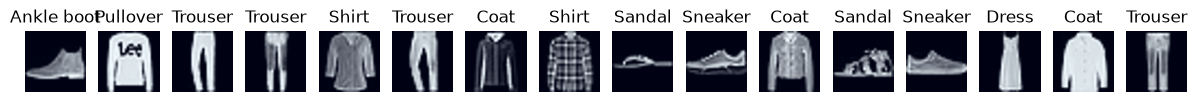

100%|██████████| 625/625 [33:39<00:00,  3.23s/it]  

Zero-shot CLIP accuracy: 0.6240


In [24]:
#Original model but removing shuffle
test_loader =DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False, # keep order 
    collate_fn=collate_clip
)
show_batch(test_loader)

y_true, y_pred = [], []

for pixel_values, labels in tqdm(test_loader):
#Build text embeddings for the class names using the get_text_embeddings function (this only needs to be done once).
    text_feats = get_text_embeddings(CLASS_NAMES)
# Get image embeddings using the get_image_embeddings function.
    image_embeddings = get_image_embeddings(pixel_values)
#Compute cosine similarity between the image and text embeddings using the get_cosine_similarity function.
    similarity_scores = get_cosine_similarity(image_embeddings, text_feats)
# Save the predictions so that we can build a confusion matrix later.
    predictions = get_predictions(similarity_scores)

    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predictions.cpu().numpy())

# Report the accuracy of the predictions
#Report the accuracy of the predictions and the confusion matrix using the accuracy_score and confusion_matrix functions from sklearn.metrics
acc = accuracy_score(y_true, y_pred)
print(f"Zero-shot CLIP accuracy: {acc:.4f}")


# Convert to numpy arrays the zero-shot classification
y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [28]:
#Combine CNN and CLIP predictions.
def updated_predict(cnn_preds, cnn_conf, clip_preds, threshold=0.8):
    # Convert data to be able to compare
    cnn_preds = np.array(cnn_preds)
    cnn_conf = np.array(cnn_conf)
    clip_preds = np.array(clip_preds)
    
    hybrid_preds = cnn_preds.copy()
    low_conf_mask = cnn_conf < threshold #Find cases where CNN confidence is low
    hybrid_preds[low_conf_mask] = clip_preds[low_conf_mask] #Replace low confidence CNN predictions with CLIP predictions
    
    return hybrid_preds

def evaluate_update(y_true, cnn_preds, cnn_conf, clip_preds, threshold=0.8):
    hybrid_preds = updated_predict(cnn_preds, cnn_conf, clip_preds, threshold)
    accuracy = accuracy_score(y_true, hybrid_preds)
    return accuracy, hybrid_preds


In [29]:
# Test different thresholds
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
updated_accuracies = []
updated_predictions = {}

for threshold in thresholds:
    acc, preds = evaluate_update(y_true, cnn_pred_classes, cnn_conf, y_pred, threshold)
    updated_accuracies.append(acc)
    updated_predictions[threshold] = preds
    print(f"Threshold {threshold}: Hybrid Accuracy = {acc*100:.2f}%")

# Find best threshold
best_threshold = thresholds[np.argmax(updated_accuracies)]
best_accuracy = max(updated_accuracies)

Threshold 0.5: Hybrid Accuracy = 89.64%
Threshold 0.6: Hybrid Accuracy = 89.47%
Threshold 0.7: Hybrid Accuracy = 88.96%
Threshold 0.8: Hybrid Accuracy = 88.05%
Threshold 0.9: Hybrid Accuracy = 86.82%


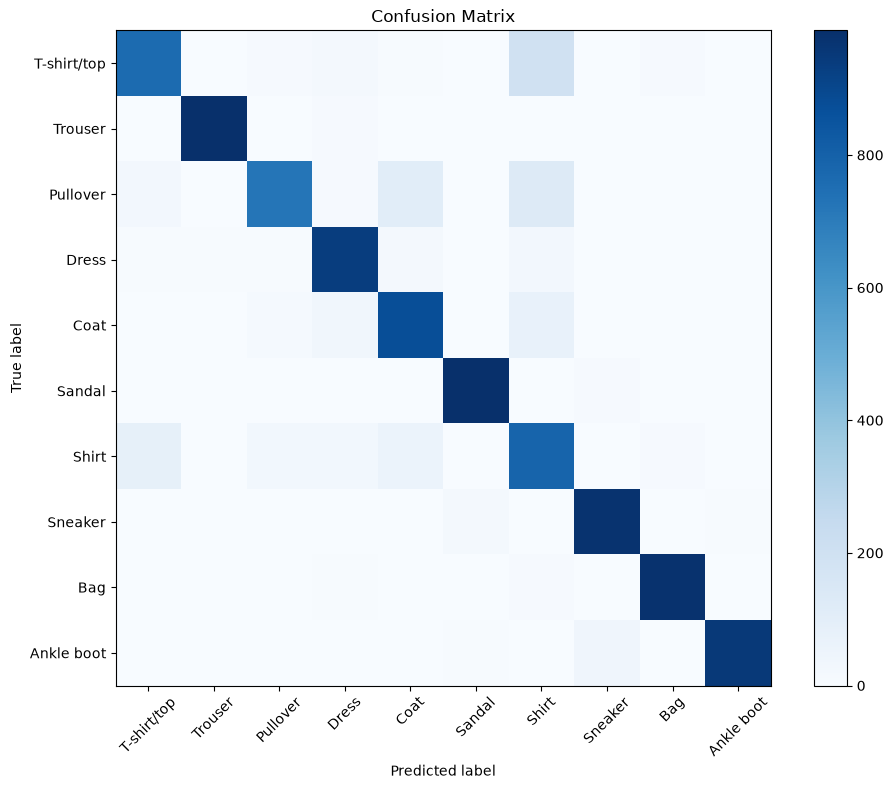

In [30]:
# Plot Hybrid Confusion Matrix (best threshold)
plot_confusion_matrix(y_true, updated_predictions[best_threshold], CLASS_NAMES)

### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

- **Introduction** The mini-experiment objetive was to combine the CNN and the CLIP's zero-shot model to improve calssification accurancy, by combining predictions: if the predicction was good then CNN prediction will be used, otherwise we will check the CLIP prediction
- **Methodology**: \
        -- Use the best CNN in assignment-1, train it and evaluate it.\
        -- Use the same model in assingment-2, by changing the DataLoader parameters.\
        -- Then create a function hybrid_predict to replace the exchange the prediction if the CNN confidence was below a threshold.\
        -- Try with different threshold
- **Results**: The best performance was 89.64% accurancy at a threshold of .5 and higher thresholds  get lower accurancy. plot_confusion_matrix for the best threshold shows a better perfomance vs CLIP's zero-shot model
- **Discussion**: The mini-experiment did not improve over CNN, because CNN was already good,  


🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.